# Exploring Priority BFS 

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import datetime

In [24]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [38]:
colnames = ["time_interval", "id_1", "id_2", "class_id_1", "class_id_2"]

df_2012 = pd.read_csv(
    "thiers_2012.csv",
    sep="\t",
    header=None,
    names=colnames
)

# Convert to datetime (UTC)
df_2012["datetime_utc"] = pd.to_datetime(df_2012["time_interval"], unit="s", utc=True)

print("2012 interactions:")
display(df_2012.head())








2012 interactions:


,time_interval,id_1,id_2,class_id_1,class_id_2,datetime_utc
0,1353303380,1170,1644,MP*1,MP*1,2012-11-19 05:36:20+00:00
1,1353303400,1170,1613,MP*1,MP*1,2012-11-19 05:36:40+00:00
2,1353303640,1170,1644,MP*1,MP*1,2012-11-19 05:40:40+00:00
3,1353303760,1181,1651,MP*1,MP*1,2012-11-19 05:42:40+00:00
4,1353303840,1108,1190,MP*1,MP*1,2012-11-19 05:44:00+00:00


# Testing NetworkRugs on our new data

> **Events → Windows → Graphs → Ordering → NetworkRug → Interpretation**

### Phase A: Turn data data into snapshots (most important step)+ choose a time granularity
Rule of thumb: too fine → noise, too coarse → nothing happens


### Defining the window

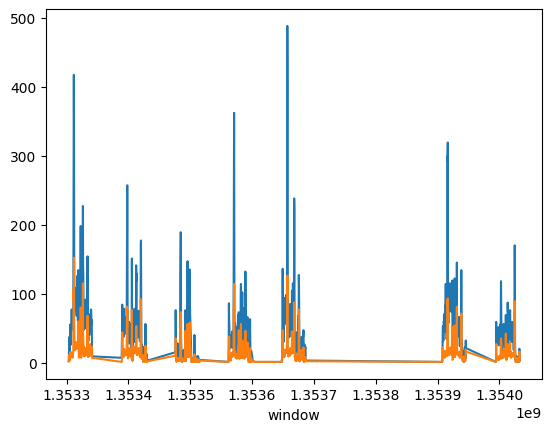

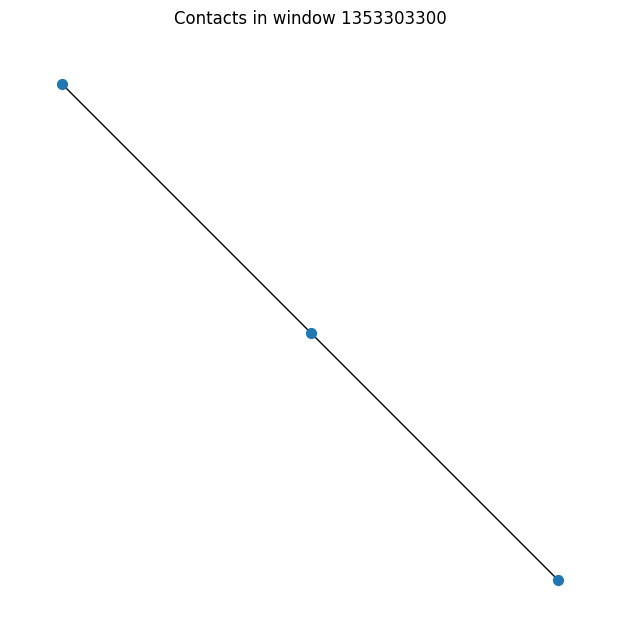

In [27]:
# Creating window column
window = 300  # 5 minutes in seconds
df_2012["window"] = (df_2012["time_interval"] // window) * window

# Interactions per window overview
interactions_per_window = (
    df_2012
    .groupby("window")
    .size()
)

interactions_per_window.plot()

# How many unique pairs per window? Since we are NOT USING WEIGHTS YET, have to count each interaction within the window only once
df_2012["u"] = df_2012[["id_1", "id_2"]].min(axis=1)
df_2012["v"] = df_2012[["id_1", "id_2"]].max(axis=1)

unique_pairs_per_window = (
    df_2012
    .drop_duplicates(subset=["window", "u", "v"])
    .groupby("window")
    .size()
)
unique_pairs_per_window.plot()

# Visualizing a single window network
one_window = df_2012["window"].iloc[0]
df_w = df_2012[df_2012["window"] == one_window]
# Deduplicating edges
edges = df_w.drop_duplicates(subset=["u", "v"])

G = nx.from_pandas_edgelist(edges, "u", "v")

plt.figure(figsize=(6, 6))
nx.draw(G, node_size=50, with_labels=False)
plt.title(f"Contacts in window {one_window}")
plt.show()





### Phase B: Build snapshot graphs

For each time step ( t ):
```text
G_t = (V_t, E_t)
```



In [28]:
# ensuring global node setting (reference roster of students)
nodes = pd.unique(df_2012[["id_1", "id_2"]].values.ravel())
print(f"Total unique students: {len(nodes)}")


Total unique students: 180


### Important question: Do we want to visualize the empty (non-interaction) windows?
### If no, we remove them from our data:

In [29]:
# this filters out windows without any interactions, meaning they don't show up in network rugs
# building snapshot graphs per window
graphs = {}

for w, df_w in df_2012.groupby("window"):
    G = nx.Graph()
    
    # add all nodes (stable across time)
    G.add_nodes_from(nodes)
    
    # deduplicate edges within the window
    edges = df_w.drop_duplicates(subset=["u", "v"])
    G.add_edges_from(edges[["u", "v"]].itertuples(index=False)) # Prevents multiple identical (u,v) edges from being added, adds edges to each graph
    
    graphs[w] = G # storing graph for this 



<Axes: title={'center': 'snapshot structure over time'}, xlabel='window'>

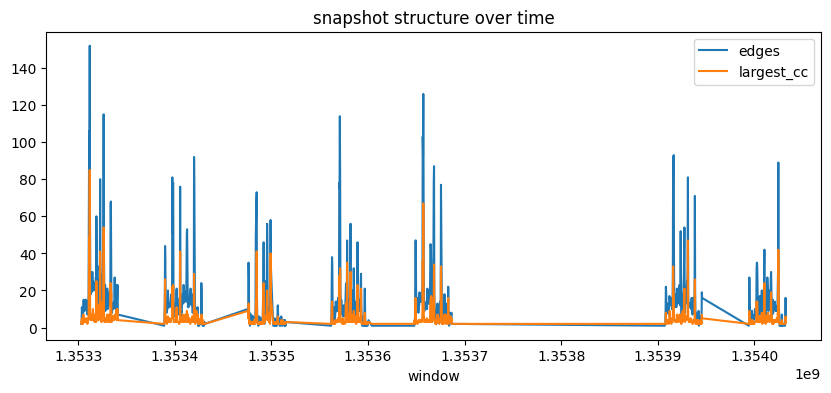

In [30]:
# number of edges per snapshot - Is there any interaction in this window?
edges_per_window = {
    w: G.number_of_edges() for w, G in graphs.items()
}

# connected components - Is the network fragmented into many isolated pieces?
components_per_window = {
    w: nx.number_connected_components(G) for w, G in graphs.items()
}

# largest connected component - Is there a group, not just pairs?
largest_cc = {}

for w, G in graphs.items():
    if G.number_of_edges() == 0:
        largest_cc[w] = 0
    else:
        largest_cc[w] = len(max(nx.connected_components(G), key=len))

# summarz for comparisons
summary_df = pd.DataFrame({
    "window": list(graphs.keys()),
    "edges": list(edges_per_window.values()),
    "largest_cc": list(largest_cc.values())
}).sort_values("window")

summary_df.plot(
    x="window",
    y=["edges", "largest_cc"],
    figsize=(10, 4),
    title="snapshot structure over time"
)



The graph helps us because with Priority-BFS and NetworkRugs we:

- do not care how many times two nodes met

- however we do care whether the network has dense local neighborhoods

**largest_cc** : How many students are connected together in the largest group, tells us if there is a group or just isolated pairs in each snapshot

### Including empty windows for comparison

In [31]:
graphs_with_empty_windows = {}

all_windows = np.arange(
    df_2012["window"].min(),
    df_2012["window"].max() + window,
    window
)

for w in all_windows:
    G = nx.Graph()
    G.add_nodes_from(nodes)

    df_w = df_2012[df_2012["window"] == w]

    if not df_w.empty:
        edges = df_w.drop_duplicates(subset=["u", "v"])
        G.add_edges_from(edges[["u", "v"]].itertuples(index=False))

    graphs_with_empty_windows[w] = G    

### Printing first window when applying Priority-BFS

In [34]:
from ba_utils.orderings import get_priority_bfs_ordering, get_start_node
from ba_utils.network_rugs import draw_rug_from_graphs

prio_bfs_ordering = get_priority_bfs_ordering(graphs)

"""    Select a single consistent start node, either:
      - 'highest' / 'lowest':   extreme on the first graph
      - 'highest_global' / 'lowest_global': extreme aggregated across all graphs
"""

start_nodes = get_start_node(graphs, metric='degree', mode='lowest_global')

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)

Global stats: ((1, 1), (0, 15), (0, 7))
Priority BFS Ordering:
num_artists 1


In [33]:
# Get all timestamps in sorted order
timestamps = sorted(prio_bfs_ordering.keys())

# 1️⃣ First window (earliest timestamp)
first_ts = timestamps[0]
first_window_nodes = prio_bfs_ordering[first_ts]
print(f"Timestamp {first_ts}: nodes in priority BFS order:")
print(first_window_nodes)

# 2️⃣ First 20 windows
for ts in timestamps[:20]:
    window_nodes = prio_bfs_ordering[ts]
    print(f"Timestamp {ts}: {len(window_nodes)} nodes")
    print(window_nodes)

Timestamp 1353303300: nodes in priority BFS order:
[600]
Timestamp 1353303300: 1 nodes
[600]
Timestamp 1353303600: 1 nodes
[600]
Timestamp 1353303900: 1 nodes
[600]
Timestamp 1353304200: 1 nodes
[600]
Timestamp 1353304500: 1 nodes
[600]
Timestamp 1353304800: 1 nodes
[600]
Timestamp 1353305100: 1 nodes
[600]
Timestamp 1353305400: 1 nodes
[600]
Timestamp 1353305700: 1 nodes
[600]
Timestamp 1353306000: 1 nodes
[600]
Timestamp 1353306300: 1 nodes
[600]
Timestamp 1353306600: 1 nodes
[600]
Timestamp 1353306900: 1 nodes
[600]
Timestamp 1353307200: 3 nodes
[600, 609, 690]
Timestamp 1353307500: 3 nodes
[600, 609, 690]
Timestamp 1353307800: 1 nodes
[600]
Timestamp 1353308100: 3 nodes
[600, 609, 690]
Timestamp 1353308400: 5 nodes
[600, 609, 613, 658, 690]
Timestamp 1353308700: 4 nodes
[600, 609, 613, 690]
Timestamp 1353309000: 3 nodes
[600, 613, 658]


In [37]:
for ts, nodes in prio_bfs_ordering.items():
    print(f"{ts}: {len(nodes)} nodes -> {nodes[:10]}")  # first 10 nodes

1353303300: 1 nodes -> [600]
1353303600: 1 nodes -> [600]
1353303900: 1 nodes -> [600]
1353304200: 1 nodes -> [600]
1353304500: 1 nodes -> [600]
1353304800: 1 nodes -> [600]
1353305100: 1 nodes -> [600]
1353305400: 1 nodes -> [600]
1353305700: 1 nodes -> [600]
1353306000: 1 nodes -> [600]
1353306300: 1 nodes -> [600]
1353306600: 1 nodes -> [600]
1353306900: 1 nodes -> [600]
1353307200: 3 nodes -> [600, 609, 690]
1353307500: 3 nodes -> [600, 609, 690]
1353307800: 1 nodes -> [600]
1353308100: 3 nodes -> [600, 609, 690]
1353308400: 5 nodes -> [600, 609, 613, 658, 690]
1353308700: 4 nodes -> [600, 609, 613, 690]
1353309000: 3 nodes -> [600, 613, 658]
1353309300: 4 nodes -> [600, 613, 609, 658]
1353309600: 1 nodes -> [600]
1353309900: 3 nodes -> [600, 609, 690]
1353310200: 3 nodes -> [600, 609, 690]
1353310500: 3 nodes -> [600, 609, 690]
1353310800: 1 nodes -> [600]
1353311100: 1 nodes -> [600]
1353311400: 5 nodes -> [600, 866, 871, 854, 634]
1353311700: 5 nodes -> [600, 634, 866, 854, 871]

weird, seems as though there are many many timestamps where there is only 1 node (there should be at least one if each timestamp contains at least one interaction/edge)
To Do:
- investigate whether the graphs are being built correctly (why is there only a single node in many timestamps)
- this still doesnt fix the issue with traversing

Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3
Global stats: ((1, 1), (0, 15), (0, 7))
num_artists 3


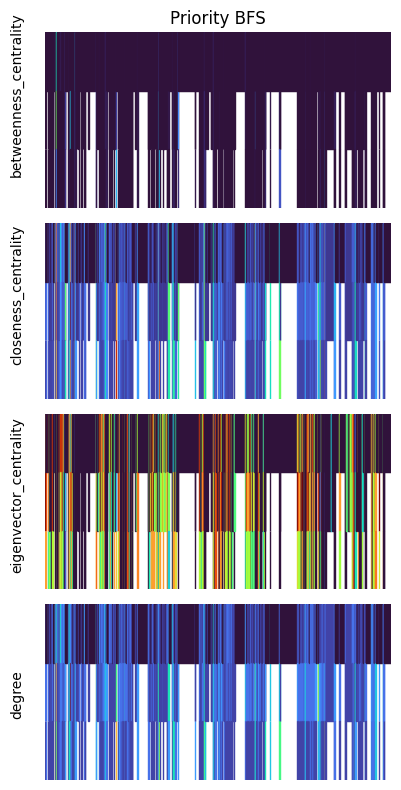

In [76]:
from ba_utils.orderings import get_start_node

# Choose strategy: 
# metric has options: degree, closeness_centrality
# 'highest_global' = highest average metric across all time
start_nodes = get_start_node(graphs, metric='degree', mode='highest_global')

orders = {
    "Priority BFS": "priority",
}

color_encodings = ['betweenness_centrality', 'closeness_centrality', 'eigenvector_centrality','degree']

# The rest of your code remains the same
fig = draw_networkrug_matrix_with_y_labels_with_frederike_wrapper(
    graphs=graphs,
    orders=orders,
    color_encodings=color_encodings,
    pixel_size=6,
    start_nodes=start_nodes
)

plt.show()

Frederike consistently initialized DFS, BFS and Priority BFS using the node with highest betweenness centrality accross among all time steps (p.24 thesis)


### Why Priority BFS might not be working


Priority BFS Ordering:
num_artists 180


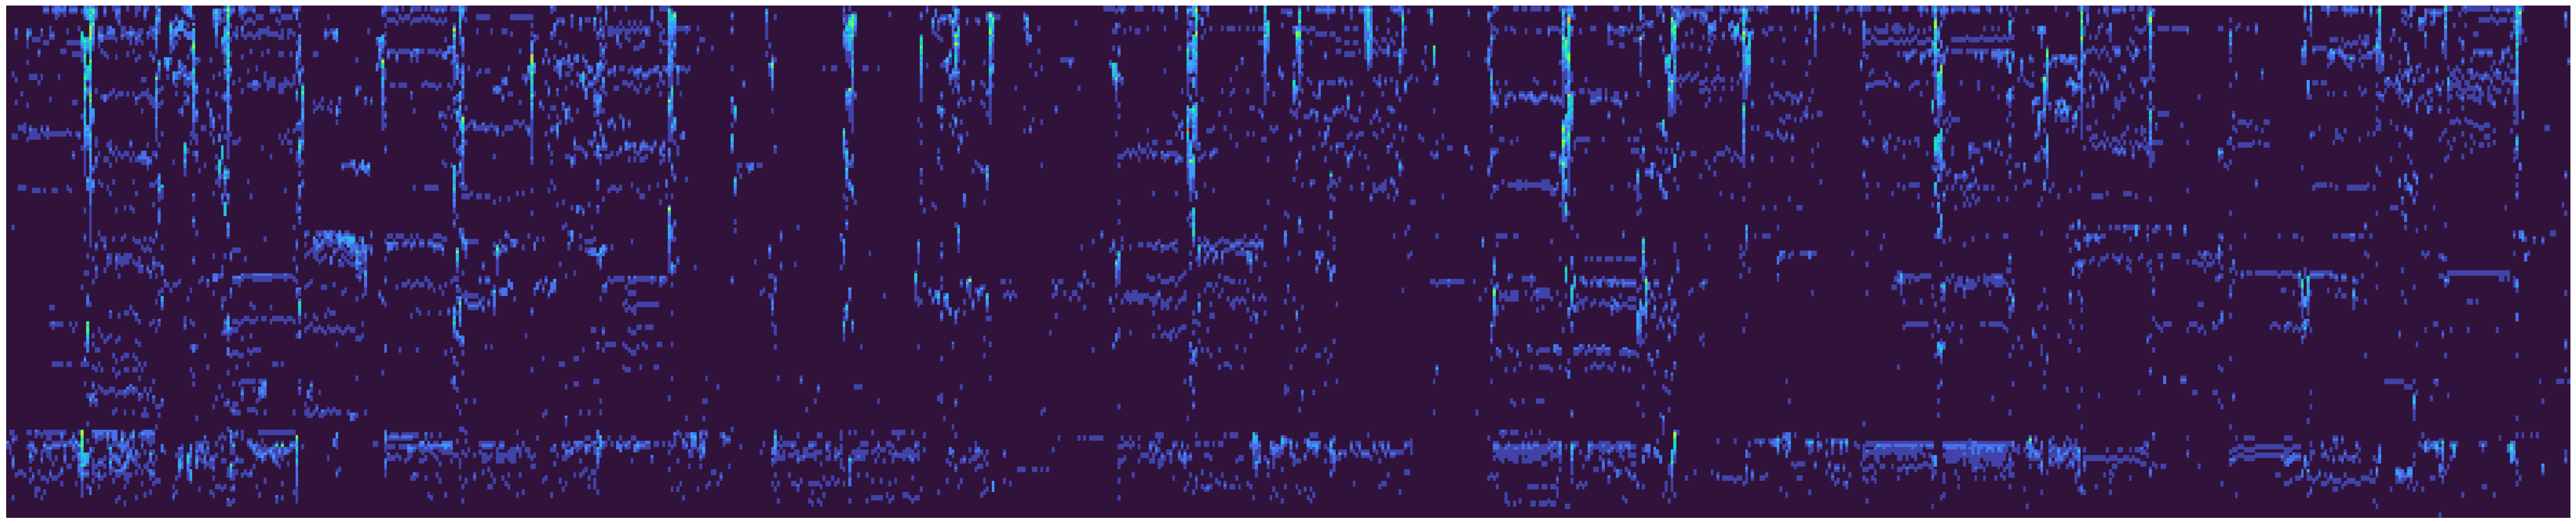

In [57]:
from ba_utils.orderings import get_priority_bfs_ordering_2
prio_bfs_ordering = get_priority_bfs_ordering_2(graphs)

print("Priority BFS Ordering:")
draw_rug_from_graphs(
    graphs_data=graphs,
    ordering=prio_bfs_ordering,
    color_encoding="degree",
    pixel_size=6
)



this is the exact same visualization obtained from bfs with degree color encoding...

In [59]:
# Assuming you have 'bfs_orders' and 'priority_orders'
ts = list(graphs.keys())[0]  # Check the first timestamp

if bfs_ordering[ts] == prio_bfs_ordering[ts]:
    print("The orderings are identical.")
else:
    # Find where they start to differ
    for i, (b, p) in enumerate(zip(bfs_ordering[ts], prio_bfs_ordering[ts])):
        if b != p:
            print(f"Difference starts at index {i}: BFS has {b}, Priority has {p}")
            break

The orderings are identical.


so... it didn't really work, because the make shift solution for the prio bfs turned it into a bfs